In [32]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import metrics as m
import scipy.spatial as sp

**Model**

In [46]:

#Parameters
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
seed = 42
hidden_size = 10
num_epochs = 2000
lr = 0.01
loss_history = []
representation_history = []

torch.manual_seed(seed)

#Toy model
model = nn.Sequential(
    nn.Linear(1, hidden_size),
    nn.ReLU(),
    nn.Linear(hidden_size, 1)
).to(device)

#Data
x = torch.linspace(-1, 1, 100).unsqueeze(1).to(device)
y = x**2 + 0.1

#Loss and optimizer
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
noise_std = 0.2

#Training loop
for epoch in range(num_epochs):
    model.train()
    outputs = model(x)
    loss = loss_fn(outputs, y)

    optimizer.zero_grad()
    loss.backward()

    # Add noise to the gradient updates before stepping
    for param in model.parameters():
        if param.grad is not None:
            param.grad += torch.randn_like(param.grad) * noise_std
    optimizer.step()

    #Extract representation from the hidden layer
    with torch.no_grad():
        hidden_representation = model[0](x)  # Get the output of the first linear layer
        hidden_representation = model[1](hidden_representation)  # Apply ReLU activation
    
    representation_history.append(hidden_representation.cpu().numpy())
    loss_history.append(loss.item())
    
    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/2000], Loss: 0.0830
Epoch [200/2000], Loss: 0.0699
Epoch [300/2000], Loss: 0.0583
Epoch [400/2000], Loss: 0.0498
Epoch [500/2000], Loss: 0.0430
Epoch [600/2000], Loss: 0.0361
Epoch [700/2000], Loss: 0.0275
Epoch [800/2000], Loss: 0.0193
Epoch [900/2000], Loss: 0.0165
Epoch [1000/2000], Loss: 0.0130
Epoch [1100/2000], Loss: 0.0108
Epoch [1200/2000], Loss: 0.0082
Epoch [1300/2000], Loss: 0.0079
Epoch [1400/2000], Loss: 0.0071
Epoch [1500/2000], Loss: 0.0067
Epoch [1600/2000], Loss: 0.0066
Epoch [1700/2000], Loss: 0.0059
Epoch [1800/2000], Loss: 0.0068
Epoch [1900/2000], Loss: 0.0060
Epoch [2000/2000], Loss: 0.0059


**Metrics and Analysis**

In [49]:
compared = 1500

cka = m.CKA(representation_history[0], representation_history[compared])
print(f'CKA similarity between initial and compared representations: {cka:.4f}')

cosine_sim = m.cosine_similarity(representation_history[0], representation_history[compared])
print(f'Cosine similarity between initial and compared representations: {cosine_sim:.4f}')

_,_,disparity = sp.procrustes(representation_history[0], representation_history[compared])
print(f'Procrustes distance between initial and compared representations: {disparity:.4f}')

pr = m.participation_ratio(representation_history[compared])
print(f'Participation Ratio of compared representation: {pr:.4f}')


CKA similarity between initial and compared representations: 0.9971
Cosine similarity between initial and compared representations: 0.9885
Procrustes distance between initial and compared representations: 0.0123
Participation Ratio of compared representation: 1.2012


**Plotting**

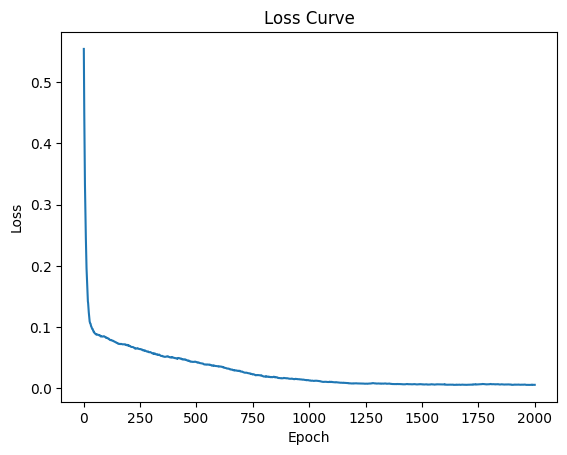

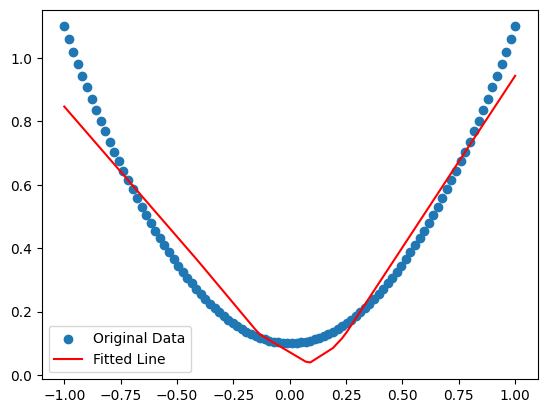

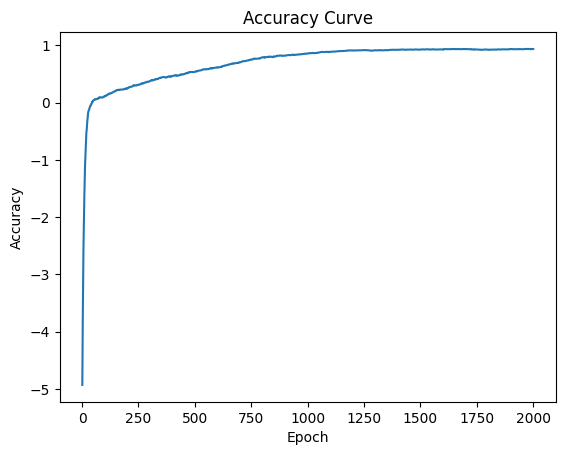

In [47]:
#plotting loss curve
plt.plot(range(1, num_epochs+1), loss_history)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.show()
        
#Plotting results
model.eval()
with torch.no_grad():
    predicted = model(x).cpu().numpy()
    plt.scatter(x.cpu(), y.cpu(), label='Original Data')
    plt.plot(x.cpu(), predicted, label='Fitted Line', color='red')
    plt.legend()
    plt.show()
    
#plotting accuracy curve
accuracy_history = [1 - (loss / y.var()).item() for loss in loss_history]
plt.plot(range(1, num_epochs+1), accuracy_history)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.show()